In [1]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [3]:

np.random.seed(42)

# Define hospital departments
departments = [
"Radiology","Pharmacy","Patient Records","Telemedicine",
"Billing","Emergency","ICU","Laboratory","Surgery",
"Cardiology","Neurology","Oncology","Pediatrics",
"Administration","Insurance Processing"
]

# Define cloud services
services = [
"Compute","Storage","Database","AI Services",
"Backup","Monitoring","Security","Analytics",
"Image Processing","EHR Systems"
]

# Generate hourly timestamps for the entire year 2025
timestamps = pd.date_range(
    start="2025-01-01 00:00:00",
    end="2025-12-31 23:00:00",
    freq="h"
)

records = len(timestamps)

# Create dataset
data = {
"timestamp": timestamps,
"department": np.random.choice(departments, records),
"service_type": np.random.choice(services, records),
"compute_hours": np.random.uniform(1,24,records),
"storage_usage_gb": np.random.uniform(10,500,records),
"data_transfer_gb": np.random.uniform(5,200,records),
"api_requests": np.random.randint(100,10000,records),
"active_users": np.random.randint(10,500,records),
"cpu_utilization": np.random.uniform(10,95,records)
}

df = pd.DataFrame(data)

# Extract month for seasonal simulation
df["month"] = df["timestamp"].dt.month

# convert api_requests to float for seasonal adjustments
df["api_requests"] = df["api_requests"].astype(float)


# -------------------------------
# Seasonal Healthcare Workloads
# -------------------------------

# Flu season (Jan–Mar)
flu_season = df["month"].isin([1,2,3])

df.loc[flu_season & (df["department"].isin(["Telemedicine","Laboratory","Patient Records"])), "compute_hours"] *= 1.4
df.loc[flu_season & (df["department"].isin(["Telemedicine","Laboratory"])), "api_requests"] *= 1.5


# Viral infection season (Jul–Aug)
viral_season = df["month"].isin([7,8])

df.loc[viral_season & (df["department"].isin(["Emergency","ICU"])), "compute_hours"] *= 1.5


# Allergy season (Sep–Oct)
allergy_season = df["month"].isin([9,10])

df.loc[allergy_season & (df["department"]=="Pharmacy"), "api_requests"] *= 1.3

In [4]:
# -------------------------------
# Cloud Cost Calculation
# -------------------------------

df["compute_cost"] = df["compute_hours"] * 0.6
df["storage_cost"] = df["storage_usage_gb"] * 0.03
df["transfer_cost"] = df["data_transfer_gb"] * 0.05
df["api_cost"] = df["api_requests"] * 0.0001

df["cost"] = (
df["compute_cost"] +
df["storage_cost"] +
df["transfer_cost"] +
df["api_cost"]
)

In [5]:
df.head()

,timestamp,department,service_type,compute_hours,storage_usage_gb,data_transfer_gb,api_requests,active_users,cpu_utilization,month,compute_cost,storage_cost,transfer_cost,api_cost,cost
0,2025-01-01 00:00:00,ICU,Compute,9.261448,119.609455,74.730982,8992.0,122,26.581323,1,5.556869,3.588284,3.736549,0.89920,13.780902
1,2025-01-01 01:00:00,Telemedicine,Database,20.089465,364.544053,95.544436,5836.5,293,16.738331,1,12.053679,10.936322,4.777222,0.58365,28.350872
2,2025-01-01 02:00:00,Pediatrics,Backup,2.701153,307.833648,113.225482,4856.0,95,38.302374,1,1.620692,9.235009,5.661274,0.48560,17.002576
3,2025-01-01 03:00:00,Insurance Processing,Database,5.024927,255.658011,161.361220,2007.0,111,37.685885,1,3.014956,7.669740,8.068061,0.20070,18.953458
4,2025-01-01 04:00:00,Neurology,AI Services,21.462956,315.770261,46.175494,1236.0,28,66.532864,1,12.877773,9.473108,2.308775,0.12360,24.783256


In [6]:
df.columns

Index(['timestamp', 'department', 'service_type', 'compute_hours',
       'storage_usage_gb', 'data_transfer_gb', 'api_requests', 'active_users',
       'cpu_utilization', 'month', 'compute_cost', 'storage_cost',
       'transfer_cost', 'api_cost', 'cost'],
      dtype='object')

In [7]:
df.shape

(8760, 15)

In [8]:
df["department"].unique()

array(['ICU', 'Telemedicine', 'Pediatrics', 'Insurance Processing',
       'Neurology', 'Laboratory', 'Billing', 'Cardiology',
       'Patient Records', 'Emergency', 'Pharmacy', 'Oncology',
       'Administration', 'Radiology', 'Surgery'], dtype=object)

In [9]:
df["service_type"].unique()

array(['Compute', 'Database', 'Backup', 'AI Services', 'Analytics',
       'Security', 'Storage', 'Monitoring', 'Image Processing',
       'EHR Systems'], dtype=object)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         8760 non-null   datetime64[ns]
 1   department        8760 non-null   object        
 2   service_type      8760 non-null   object        
 3   compute_hours     8760 non-null   float64       
 4   storage_usage_gb  8760 non-null   float64       
 5   data_transfer_gb  8760 non-null   float64       
 6   api_requests      8760 non-null   float64       
 7   active_users      8760 non-null   int32         
 8   cpu_utilization   8760 non-null   float64       
 9   month             8760 non-null   int32         
 10  compute_cost      8760 non-null   float64       
 11  storage_cost      8760 non-null   float64       
 12  transfer_cost     8760 non-null   float64       
 13  api_cost          8760 non-null   float64       
 14  cost              8760 n

In [11]:
df.isnull().sum()

timestamp           0
department          0
service_type        0
compute_hours       0
storage_usage_gb    0
data_transfer_gb    0
api_requests        0
active_users        0
cpu_utilization     0
month               0
compute_cost        0
storage_cost        0
transfer_cost       0
api_cost            0
cost                0
dtype: int64

In [12]:
df.describe()

,timestamp,compute_hours,storage_usage_gb,data_transfer_gb,api_requests,active_users,cpu_utilization,month,compute_cost,storage_cost,transfer_cost,api_cost,cost
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2025-07-02 11:30:00,12.971544,255.646995,102.039143,5119.812066,256.365753,52.967031,6.526027,7.782926,7.669410,5.101957,0.511981,21.066275
min,2025-01-01 00:00:00,1.003628,10.023581,5.001080,102.000000,10.000000,10.010961,1.000000,0.602177,0.300707,0.250054,0.010200,1.940036
25%,2025-04-02 05:45:00,6.993989,134.284472,53.040870,2597.750000,135.000000,31.742162,4.000000,4.196394,4.028534,2.652044,0.259775,16.413951
50%,2025-07-02 11:30:00,12.837185,256.820529,102.345087,5070.000000,259.000000,53.123851,7.000000,7.702311,7.704616,5.117254,0.507000,21.052935
75%,2025-10-01 17:15:00,18.806996,375.485640,150.456405,7604.250000,377.250000,74.522589,10.000000,11.284198,11.264569,7.522820,0.760425,25.748901
max,2025-12-31 23:00:00,35.970660,499.951479,199.958928,14955.000000,499.000000,94.988231,12.000000,21.582396,14.998544,9.997946,1.495500,41.842765
std,NaN,7.031086,140.647667,56.278960,2951.343758,140.647216,24.566988,3.448048,4.218652,4.219430,2.813948,0.295134,6.597990


In [13]:
df.to_csv("hospital_cloud_cost_dataset.csv", index=False)

<function matplotlib.pyplot.show(close=None, block=None)>

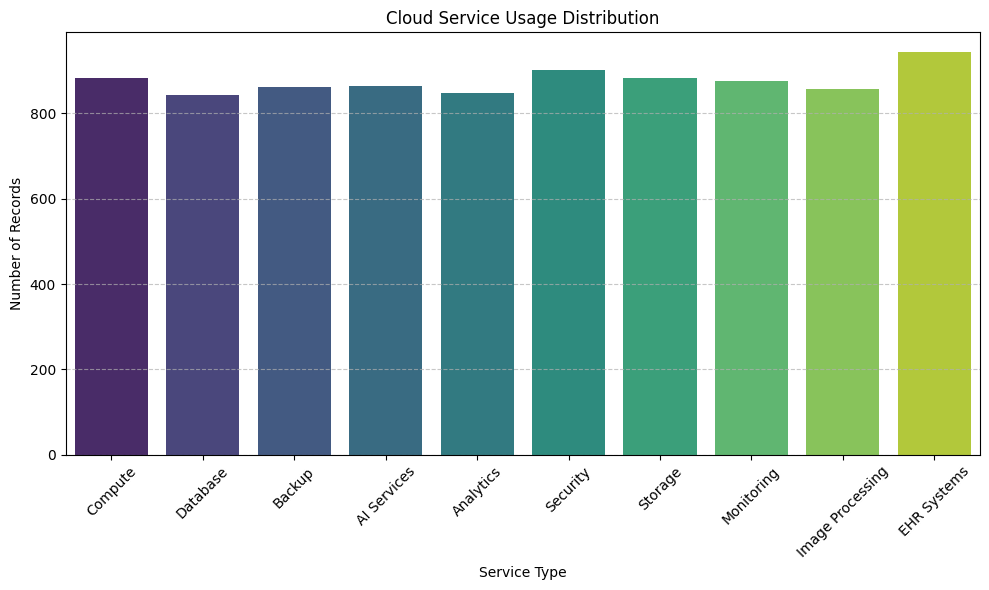

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x="service_type", hue="service_type", palette="viridis", legend=False)

plt.title("Cloud Service Usage Distribution")
plt.xlabel("Service Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig("Cloud_service_usage_distribution.png", dpi=300, bbox_inches='tight')

plt.show

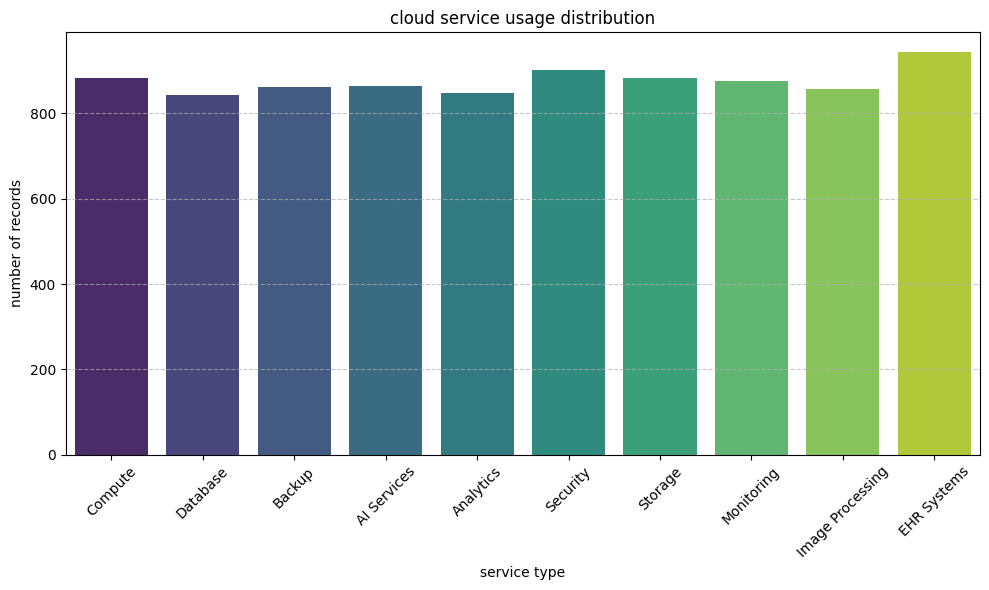

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="service_type", hue="service_type",palette="viridis",legend=False)

plt.title("cloud service usage distribution")
plt.xlabel("service type")
plt.ylabel("number of records")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--',alpha=0.7)
plt.tight_layout()
plt.savefig("cloud_service_usage_distribution.png",dpi=300,bbox_inches='tight')
plt.show()

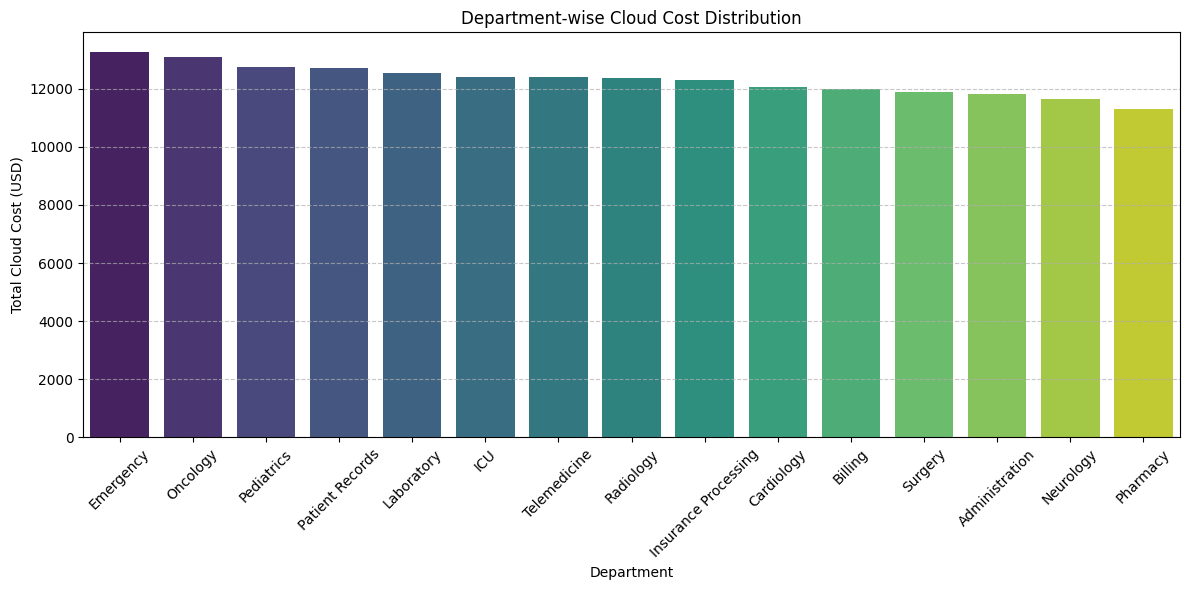

In [16]:
dept_cost = df.groupby("department")["cost"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(x=dept_cost.index, y=dept_cost.values, hue=dept_cost.index, palette="viridis", legend=False)

plt.title("Department-wise Cloud Cost Distribution")
plt.xlabel("Department")
plt.ylabel("Total Cloud Cost (USD)")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig("Department-wise_cloud_cost_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

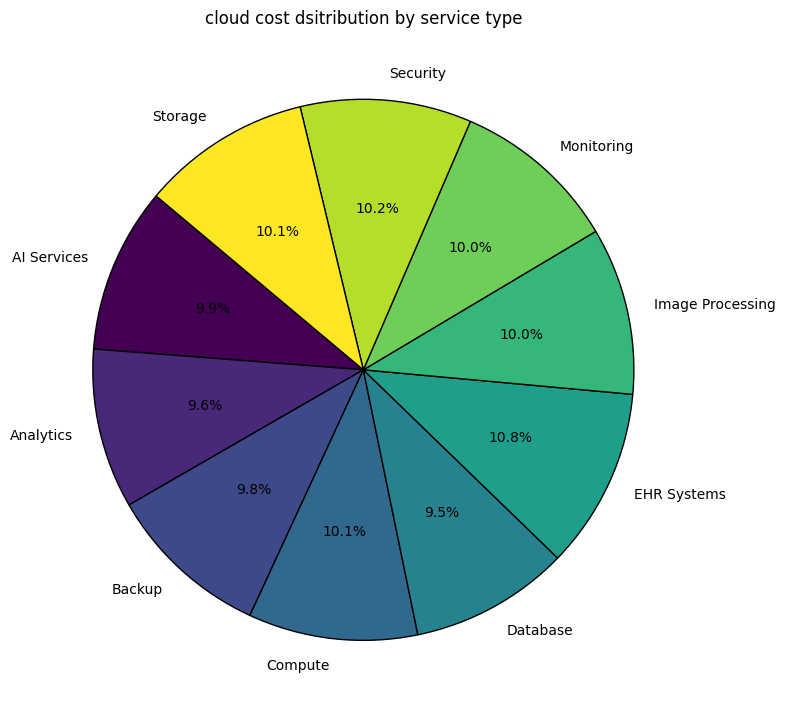

In [17]:
service_cost = df.groupby("service_type")["cost"].sum()
plt.figure(figsize=(8,8))

service_cost.plot(
kind="pie",
autopct="%1.1f%%",
startangle=140,
cmap="viridis",
wedgeprops={"edgecolor":"black"}
)

plt.title("cloud cost dsitribution by service type")
plt.ylabel("")
plt.tight_layout()
plt.savefig("cloud_cost_distribution_service_type.png",dpi=300,bbox_inches='tight')
plt.show()

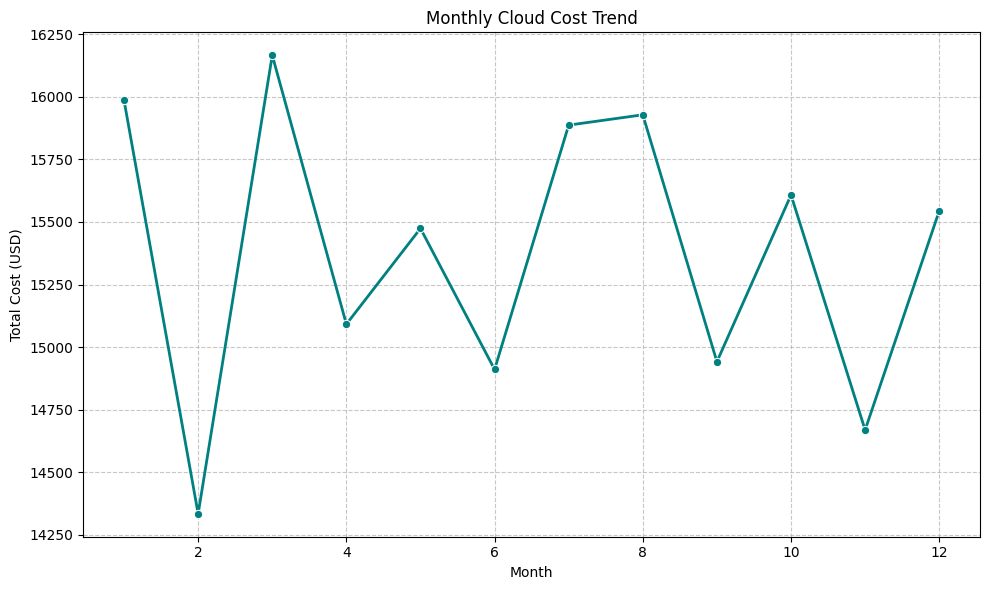

In [18]:
monthly_cost = df.groupby("month")["cost"].sum()

plt.figure(figsize=(10,6))

sns.lineplot(
    x=monthly_cost.index,
    y=monthly_cost.values,
    marker="o",
    color="teal",
    linewidth=2
)

plt.title("Monthly Cloud Cost Trend")
plt.xlabel("Month")
plt.ylabel("Total Cost (USD)")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.savefig("Monthly_cloud_cost_trend.png", dpi=300, bbox_inches='tight')

plt.show()

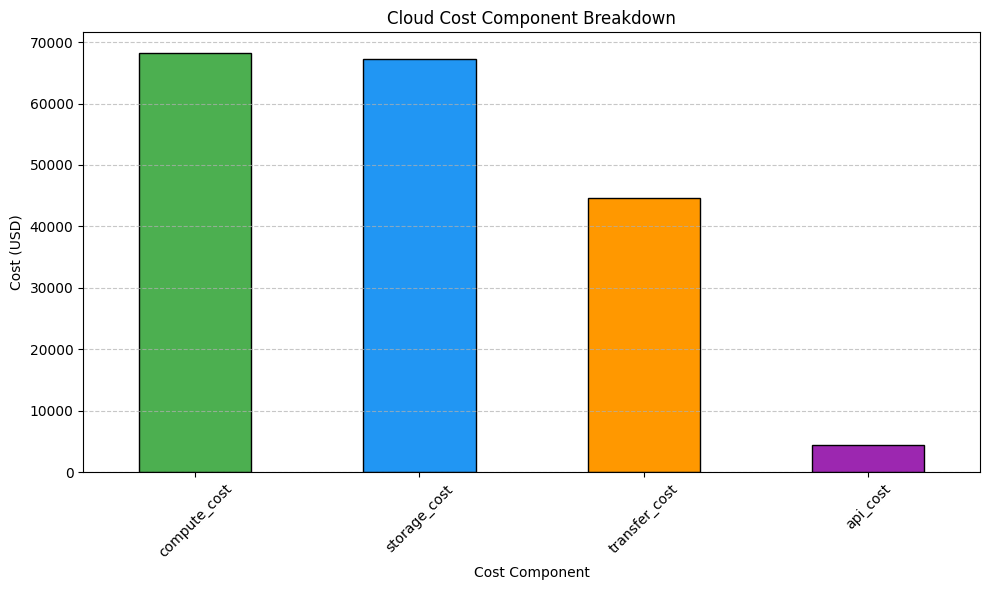

In [19]:
cost_components = df[[
"compute_cost",
"storage_cost",
"transfer_cost",
"api_cost"
]].sum()

plt.figure(figsize=(10,6))

cost_components.plot(
    kind="bar",
    color=["#4CAF50","#2196F3","#FF9800","#9C27B0"],
    edgecolor="black"
)

plt.title("Cloud Cost Component Breakdown")
plt.ylabel("Cost (USD)")
plt.xlabel("Cost Component")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.savefig("Cost_component_breakdown.png", dpi=300, bbox_inches='tight')

plt.show()

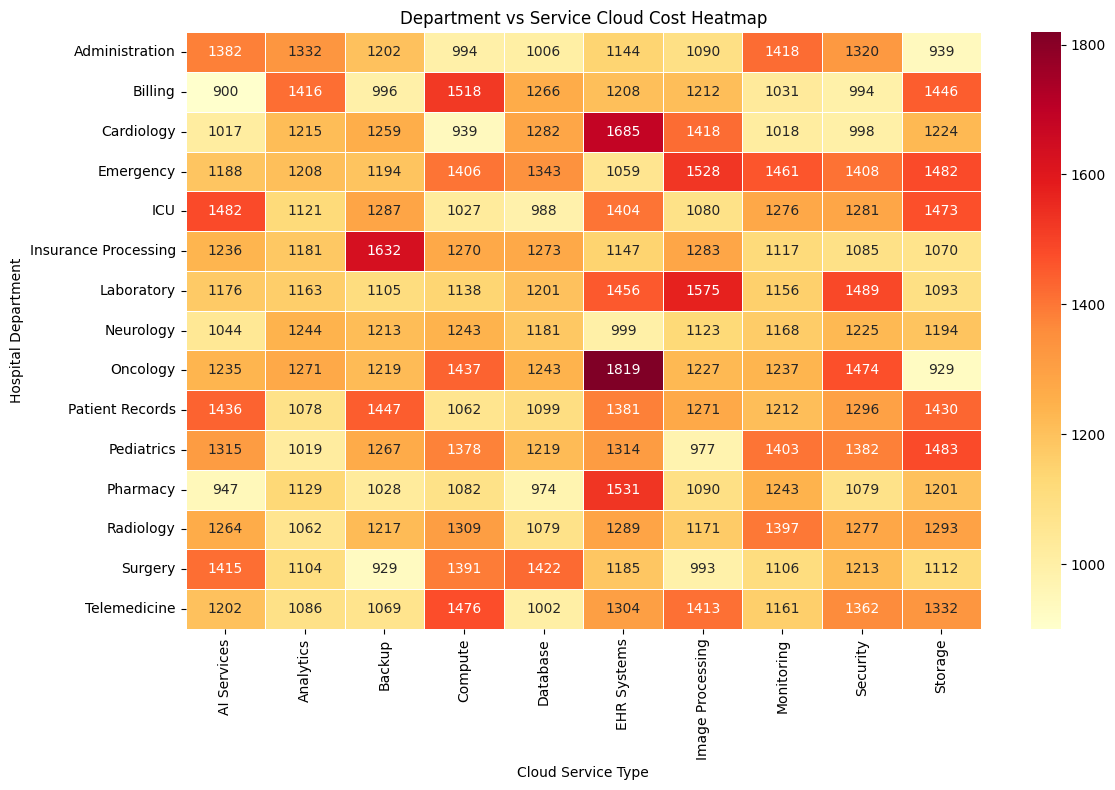

In [20]:
pivot_table=pd.pivot_table(
    df,
    values="cost",
    index="department",
    columns="service_type",
    aggfunc="sum"
)

plt.figure(figsize=(12,8))
sns.heatmap(
    pivot_table,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidth=0.5,
)
plt.title("Department vs Service Cloud Cost Heatmap")
plt.xlabel("Cloud Service Type")
plt.ylabel("Hospital Department")

plt.tight_layout()

plt.savefig("Department_vs_Service_Cloud_Cost_Heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

In [21]:
mean_cost = df["cost"].mean()
std_cost = df["cost"].std()

df["anomaly"] = df["cost"] > (mean_cost + 2*std_cost)

anomalies = df[df["anomaly"] == True]

anomalies.head()

,timestamp,department,service_type,compute_hours,storage_usage_gb,data_transfer_gb,api_requests,active_users,cpu_utilization,month,compute_cost,storage_cost,transfer_cost,api_cost,cost,anomaly
11,2025-01-01 11:00:00,ICU,Storage,23.968063,406.117127,179.934097,5523.0,101,42.508707,1,14.380838,12.183514,8.996705,0.55230,36.113356,True
23,2025-01-01 23:00:00,Laboratory,Analytics,30.556761,424.239604,161.278929,13779.0,189,65.480048,1,18.334057,12.727188,8.063946,1.37790,40.503091,True
57,2025-01-03 09:00:00,ICU,AI Services,23.924877,446.733534,151.062538,6488.0,381,17.904324,1,14.354926,13.402006,7.553127,0.64880,35.958859,True
85,2025-01-04 13:00:00,Pharmacy,Compute,17.297320,480.834203,193.150419,9062.0,79,30.579100,1,10.378392,14.425026,9.657521,0.90620,35.367139,True
107,2025-01-05 11:00:00,Laboratory,Compute,28.419716,456.426141,136.466545,13207.5,255,43.763038,1,17.051829,13.692784,6.823327,1.32075,38.888691,True


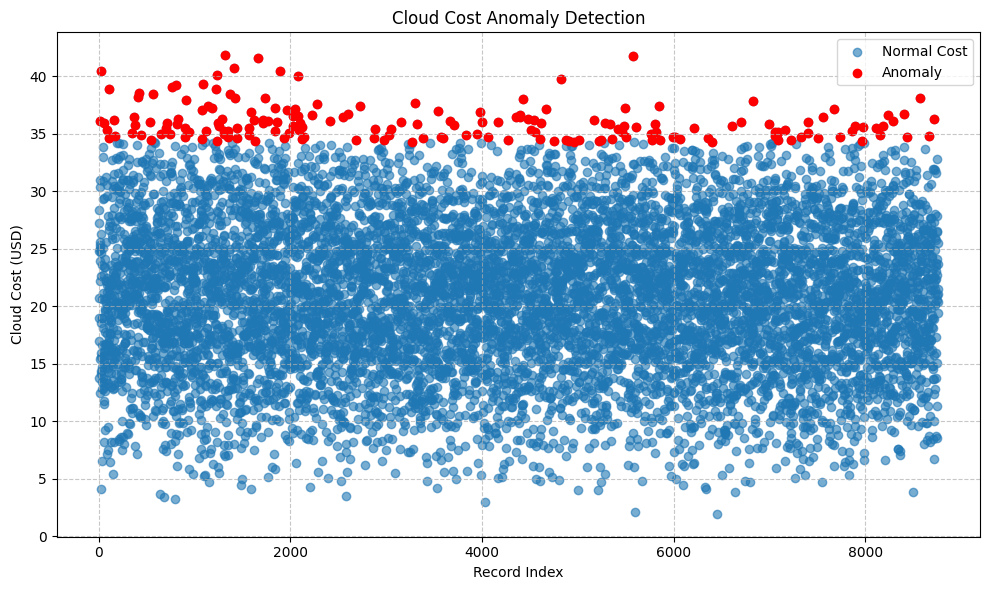

In [22]:
plt.figure(figsize=(10,6))

# Normal data points
plt.scatter(df.index, df["cost"], alpha=0.6, label="Normal Cost")

# Anomalies
plt.scatter(anomalies.index, anomalies["cost"], color="red", label="Anomaly")

plt.title("Cloud Cost Anomaly Detection")
plt.xlabel("Record Index")
plt.ylabel("Cloud Cost (USD)")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.savefig("Cloud_Cost_Anomaly_Detection.png", dpi=300, bbox_inches='tight')

plt.show()



In [23]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [25]:
X = df[["compute_hours", "storage_usage_gb", "data_transfer_gb", "api_requests"]]
Y = df["cost"]

In [26]:
X_train, X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [27]:
model = LinearRegression()
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
Y_pred = model.predict(X_test)

In [29]:
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 5.4588500133167514e-15
R2 Score: 1.0


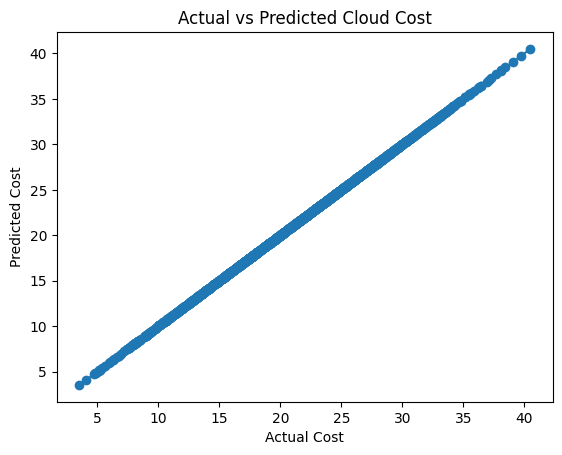

In [30]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted Cloud Cost")

# perfect prediction line (reference)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
             linestyle='--')

plt.savefig("actual_vs_predicted.png")
plt.show()

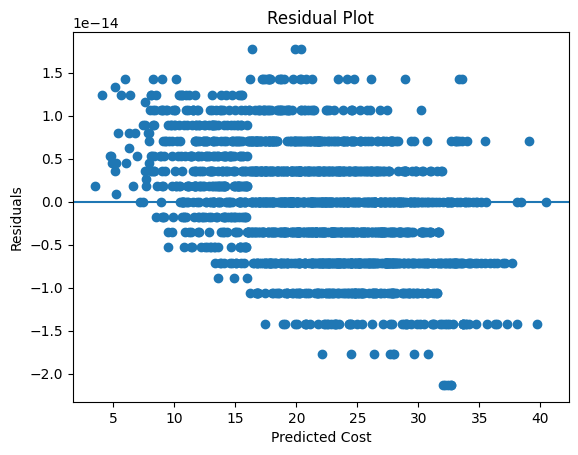

In [33]:
residuals = Y_test - Y_pred

plt.figure()
plt.scatter(Y_pred, residuals)
plt.xlabel("Predicted Cost")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.axhline(y=0)
plt.savefig("Residual Plot.png")
plt.show()

In [31]:
sample = pd.DataFrame([[10, 200, 50, 5000]],
                      columns=["compute_hours", "storage_usage_gb", "data_transfer_gb", "api_requests"])

predicted_cost = model.predict(sample)

print("Predicted Cost:", predicted_cost[0])

Predicted Cost: 14.999999999999995


In [32]:
mean_cost = df["cost"].mean()
std_cost = df["cost"].std()

threshold = mean_cost + 2 * std_cost

df["anomaly"] = df["cost"] > threshold

print("Total anomalies detected:", df["anomaly"].sum())

Total anomalies detected: 182


In [34]:
def generate_recommendations(df):

    recommendations = []

    # Department-wise high cost
    dept_cost = df.groupby("department")["cost"].sum()
    high_dept = dept_cost.idxmax()

    recommendations.append(f"{high_dept} department has the highest cloud cost. Consider optimizing its resource usage.")

    # Service-wise high cost
    service_cost = df.groupby("service_type")["cost"].sum()
    high_service = service_cost.idxmax()

    recommendations.append(f"{high_service} service contributes the most to cloud cost. Optimization is recommended.")

    # High data transfer
    high_transfer_dept = df.groupby("department")["data_transfer_gb"].mean().idxmax()
    recommendations.append(f"{high_transfer_dept} shows high data transfer usage. Consider optimizing network usage.")


    anomaly_data = df[df["anomaly"]]

    if len(anomaly_data) > 0:
        top_anomaly_depts = (
            anomaly_data.groupby("department")["cost"]
            .sum()
            .sort_values(ascending=False)
            .head(3)
            .index
        )

        recommendations.append(
            f"Major anomalies detected in departments: {', '.join(top_anomaly_depts)}. Immediate investigation is recommended."
        )

    return recommendations

In [35]:
recs = generate_recommendations(df)

for r in recs:
    print("-", r)

- Emergency department has the highest cloud cost. Consider optimizing its resource usage.
- EHR Systems service contributes the most to cloud cost. Optimization is recommended.
- Oncology shows high data transfer usage. Consider optimizing network usage.
- Major anomalies detected in departments: Laboratory, Patient Records, Telemedicine. Immediate investigation is recommended.
